Withot feature selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [3]:
df = pd.read_csv("/kaggle/input/breast-cancer-wisconsin-data/data.csv")

In [4]:
print(df.head(5))


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [5]:

print(df.shape)


(569, 33)


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
print(df.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

In [8]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [9]:
df.drop(["id","Unnamed: 32"] ,axis=1,inplace =True)

In [10]:
print(df.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [11]:
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})

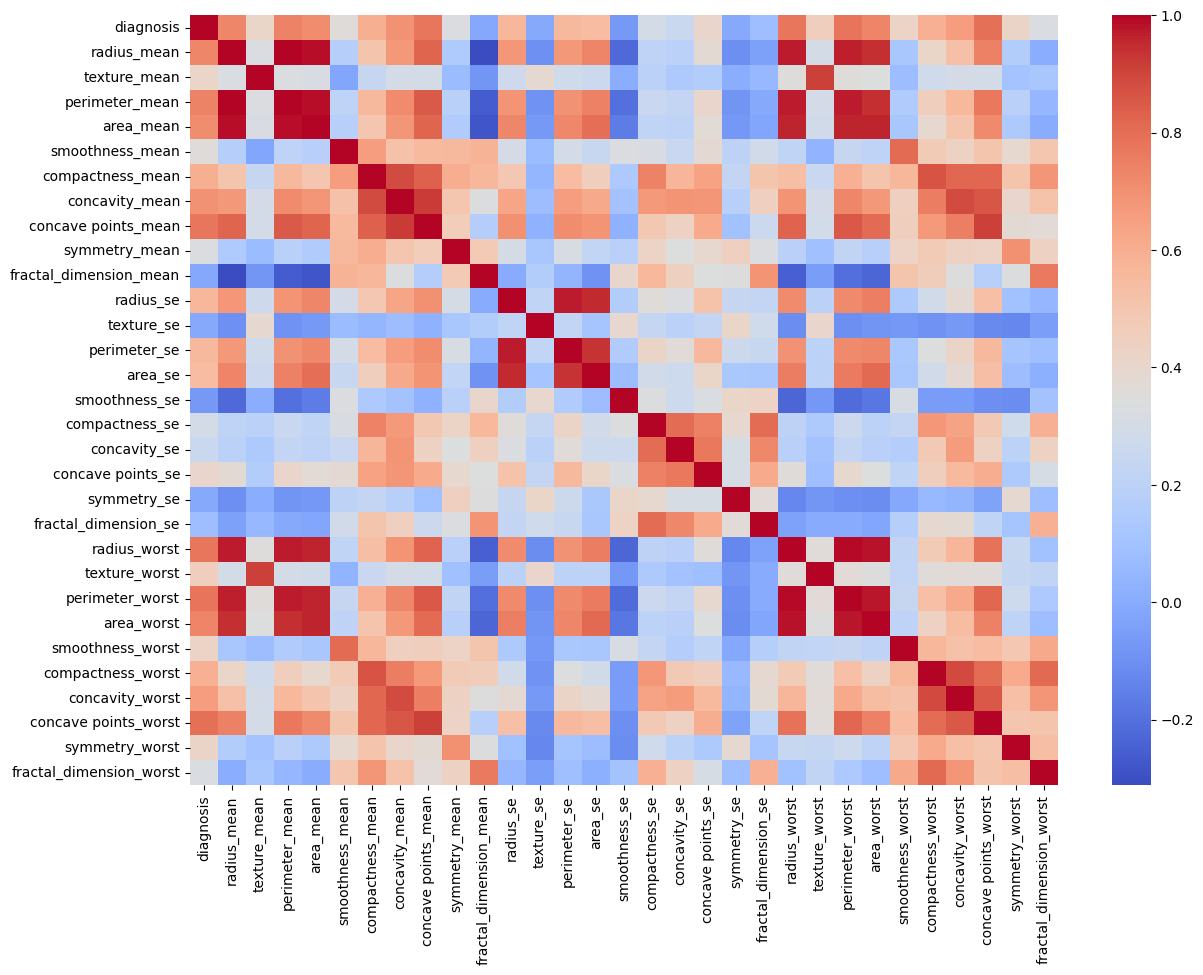

In [12]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

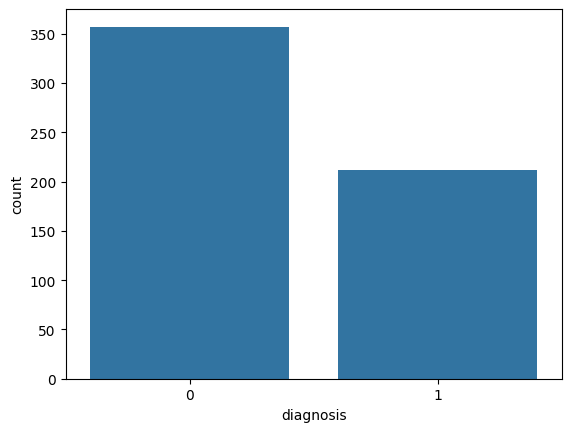

In [13]:
sns.countplot(x='diagnosis', data=df)
plt.show()

In [14]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_pred_lr))

Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC AUC: 0.9697019325253848


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))

Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC AUC: 0.9580740255486406


feature selection

In [19]:
from sklearn.linear_model import Lasso
import pandas as pd

lasso = Lasso(alpha=0.01)

lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.01)

In [21]:
selected_features = X.columns[lasso.coef_ != 0]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['texture_mean', 'concave points_mean', 'fractal_dimension_mean',
       'radius_se', 'smoothness_se', 'compactness_se', 'concavity_se',
       'radius_worst', 'texture_worst', 'smoothness_worst', 'concavity_worst',
       'concave points_worst', 'symmetry_worst'],
      dtype='object')


In [22]:
X_selected = df[selected_features]

In [23]:
from sklearn.model_selection import train_test_split

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_fs_scaled = scaler.fit_transform(X_train_fs)

X_test_fs_scaled = scaler.transform(X_test_fs)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

lr_fs = LogisticRegression(max_iter=1000)

lr_fs.fit(X_train_fs_scaled, y_train_fs)

y_pred_fs = lr_fs.predict(X_test_fs_scaled)

In [26]:
print("Accuracy:", accuracy_score(y_test_fs, y_pred_fs))

print(classification_report(y_test_fs, y_pred_fs))

print("ROC AUC:", roc_auc_score(y_test_fs, y_pred_fs))

Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC AUC: 0.9742875859810023


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_fs = RandomForestClassifier(random_state=42)

rf_fs.fit(X_train_fs, y_train_fs)
y_pred_rf_fs = rf_fs.predict(X_test_fs)

In [28]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test_fs, y_pred_rf_fs))

print(classification_report(y_test_fs, y_pred_rf_fs))

print("ROC AUC:", roc_auc_score(y_test_fs, y_pred_rf_fs))

Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC AUC: 0.9580740255486406


In [ ]:
####################

Logistic Regression Comparison

In [ ]:
| Metric              | Without FS        | With Lasso FS    |
| ------------------- | ----------------- | ---------------- |
| Accuracy            | 97.37%            | 97.37%           |
| Precision (Class 1) | 0.98              | 0.95             |
| Recall (Class 1)    | 0.95              | 0.98             |
| F1-Score            | 0.96              | 0.97             |
| ROC-AUC             | 0.9697            | 0.9743           |
| Training Time       | Higher            | Lower            |
| Feature Count       | Original Features | Reduced Features |
| Overfitting         | Slightly Higher   | Reduced          |


Accuracy remained the same after feature selection.
ROC-AUC increased from:
0.9697 → 0.9743

This means:

model separates classes slightly better after feature selection.
Recall Improved
0.95 → 0.98

This is important because:

fewer positive cases are missed.
Computational Efficiency

After Lasso:

fewer features used
training becomes faster
memory usage decreases
Overfitting

Feature selection removed irrelevant/noisy features:

model becomes simpler
generalization improves slightly

Random Forest Comparison

In [ ]:
| Metric        | Without FS        | With Lasso FS    |
| ------------- | ----------------- | ---------------- |
| Accuracy      | 96.49%            | 96.49%           |
| Precision     | 0.98              | 0.98             |
| Recall        | 0.93              | 0.93             |
| F1-Score      | 0.95              | 0.95             |
| ROC-AUC       | ~0.958            | ~0.958           |
| Training Time | Higher            | Lower            |
| Feature Count | Original Features | Reduced Features |
| Overfitting   | Slightly Higher   | Reduced          |


Accuracy Unchanged

Feature selection did not significantly change accuracy.

Reason:

Random Forest already handles irrelevant features well.
Training Efficiency Improved

After reducing features:

fewer tree splits required
training becomes faster
Overfitting Reduced Slightly

Removing noisy features:

simplifies trees
improves generalization

Overall Comparison Table

In [ ]:
| Model               | Accuracy Before FS | Accuracy After FS | ROC-AUC Before FS | ROC-AUC After FS |
| ------------------- | ------------------ | ----------------- | ----------------- | ---------------- |
| Logistic Regression | 97.37%             | 97.37%            | 0.9697            | 0.9743           |
| Random Forest       | 96.49%             | 96.49%            | 0.9581            | 0.9581           |


Number of features before Lasso: 25
Number of features after Lasso: 13